Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

Load Dataset

In [5]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Basic Info + Cleaning

In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

Visualization

🔹sales Trend

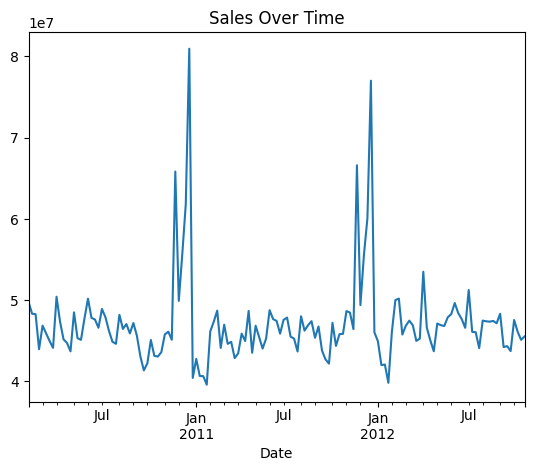

In [7]:
plt.figure()
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Sales Over Time")
plt.show()

🔹 Store-wise Sales

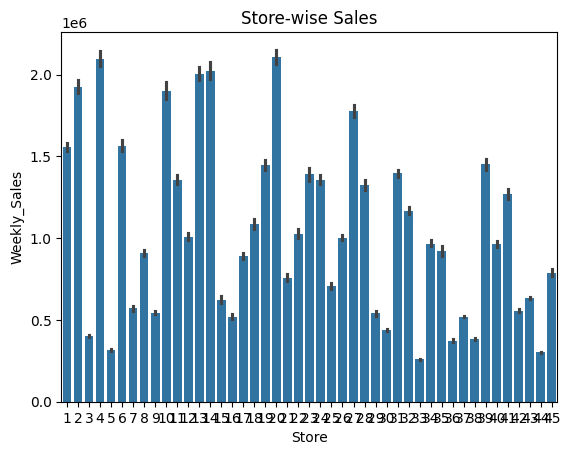

In [8]:
plt.figure()
sns.barplot(x='Store', y='Weekly_Sales', data=df)
plt.title("Store-wise Sales")
plt.show()

🔹 Holiday Impact

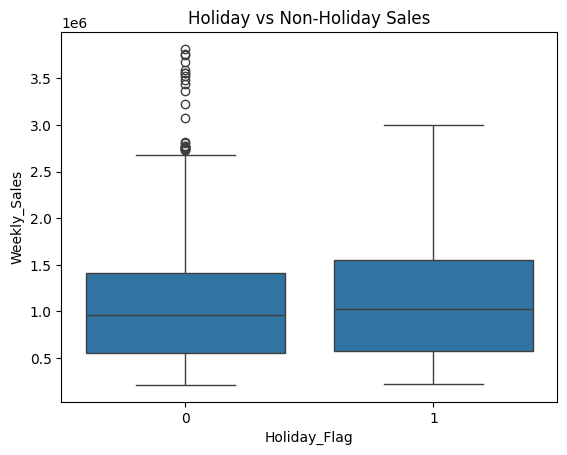

In [9]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

🔹 Correlation Heatmap

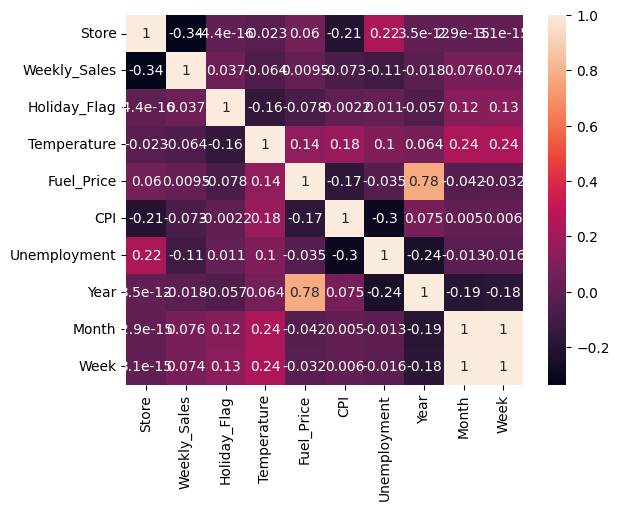

In [10]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

⚙️ Feature Selection

In [11]:
df_model = df.drop(['Date'], axis=1)

✂️  Train-Test Split

In [12]:
X = df_model.drop('Weekly_Sales', axis=1)
y = df_model['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

🤖 Model Training

In [13]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


📈 Prediction + Evaluation

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 62022.51483061383
RMSE: 114106.3394247433
R2 Score: 0.9595838205436641


💾 Save Model

In [15]:
joblib.dump(model, "walmart_model.pkl")

['walmart_model.pkl']

🔮Test Prediction (Demo)

In [16]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Sales:", prediction)

Predicted Sales: [1162385.5079]


💡 Insights Section

### Key Insights:
- Holiday weeks show higher sales
- Some stores consistently outperform others
- Seasonal trends visible in monthly sales
- Economic factors (CPI, Fuel Price) show moderate impact

In [17]:
import joblib
joblib.dump(model, "walmart_model.pkl")

['walmart_model.pkl']